In [1]:
import pandas as pd
import statsmodels.api as sm
from scipy.stats import kruskal

# Dictionary of station CSV files
stations = {
    'Station1_Revised_Final_Data.csv': 'Station 1',
    'Station2_Revised_Final_Data.csv': 'Station 2',
    'Station3_Revised_Final_Data.csv': 'Station 3',
    'Station4_Revised_Final_Data.csv': 'Station 4',
    'Station5_Revised_Final_Data.csv': 'Station 5',
    'Station6_Revised_Final_Data.csv': 'Station 6'
}

# Helper: Load Tair data grouped by time
def extract_temperature_by(file, time='year'):
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Date'}, inplace=True)

    if time == 'year':
        df['Year'] = df['Date'].dt.year
        return df.groupby('Year')['Tair'].mean()
    elif time == 'month':
        df['Month'] = df['Date'].dt.month
        return df.groupby('Month')['Tair'].mean()
    elif time == 'month_year':
        df['Year'] = df['Date'].dt.year
        df['Month'] = df['Date'].dt.month
        return df.groupby(['Month', 'Year'])['Tair'].mean().unstack()
    else:
        raise ValueError("Invalid `time` parameter.")


## Air Temperature Analysis: Kruskal-Wallis Test & Annual Trends

### Objective
To determine whether air temperature (`Tair`) varies significantly across stations and over time, and to evaluate whether any stations exhibit a long-term trend in annual average temperature.

---

### Kruskal-Wallis H-Test

The **Kruskal-Wallis test** is a non-parametric statistical test used to compare the medians of two or more groups. It does not assume normality and is well-suited for environmental data with non-normal distributions.

#### **Hypotheses**

- **Null Hypothesis (H₀):** All groups (stations or years) have the same distribution of air temperature.
- **Alternative Hypothesis (H₁):** At least one group differs in its distribution.

#### **Results**

| Test                         | H-statistic | P-value | Significant (p < 0.05) |
|-----------------------------|-------------|---------|------------------------|
| Across Stations (all years) | 7.898       | 0.1620  | No                     |
| Across Years (all stations) | 21.586      | 0.0006  | Yes                    |

- **Conclusion:** There is **significant variation** in air temperature **across years**, but not across stations.

---

### Annual Trend Analysis (OLS Regression)

Ordinary Least Squares (OLS) regression was used to estimate trends in mean annual air temperature for each station.

#### **Model**

- **Dependent variable:** Annual average `Tair`
- **Independent variable:** Year (with intercept)

#### **Results**

| Station   | Slope   | P-value | Significant (p < 0.05) |
|-----------|---------|---------|------------------------|
| Station 1 | -0.881  | 0.7981  | No                     |
| Station 2 |  0.015  | 0.8570  | No                     |
| Station 3 |  0.047  | 0.5904  | No                     |
| Station 4 |  0.055  | 0.5903  | No                     |
| Station 5 | -0.012  | 0.9590  | No                     |
| Station 6 |  0.136  | 0.1663  | No                     |

- **Conclusion:** None of the stations show statistically significant warming or cooling trends over the observed period.

---

### Interpretation

- Air temperature varies **significantly over time**, suggesting broader climate trends or year-to-year variability.
- However, there is **no evidence of long-term trends** at individual stations based on OLS regression.
- Spatially, the stations do **not** differ significantly in their overall temperature distributions.



In [2]:
# --- Trend analysis ---
trend_results = []
temp_yearly_df = pd.DataFrame()

for file, station in stations.items():
    series = extract_temperature_by(file, time='year')
    temp_yearly_df[station] = series

    if len(series.dropna()) >= 5:
        X = series.index.values.astype(int)
        X = sm.add_constant(X)
        y = series.values
        model = sm.OLS(y, X).fit()
        trend_results.append({
            'Station': station,
            'Slope': round(model.params[1], 3),
            'P-value': round(model.pvalues[1], 4),
            'Significant (p < 0.05)': 'Yes' if model.pvalues[1] < 0.05 else 'No'
        })

trend_df = pd.DataFrame(trend_results)

# --- Kruskal-Wallis Tests ---
# Across stations
station_groups = [temp_yearly_df[station].dropna().values for station in temp_yearly_df.columns]
kruskal_stat_stn, kruskal_pval_stn = kruskal(*station_groups)

# Across years
year_groups = [temp_yearly_df.loc[year].dropna().values for year in temp_yearly_df.index]
kruskal_stat_yr, kruskal_pval_yr = kruskal(*year_groups)

kruskal_df = pd.DataFrame({
    "Test": ["Across Stations (all years)", "Across Years (all stations)"],
    "H-statistic": [round(kruskal_stat_stn, 3), round(kruskal_stat_yr, 3)],
    "P-value": [round(kruskal_pval_stn, 4), round(kruskal_pval_yr, 4)],
    "Significant (p < 0.05)": ["Yes" if p < 0.05 else "No" for p in [kruskal_pval_stn, kruskal_pval_yr]]
})

# Display results
print("\nKruskal-Wallis Results:")
print(kruskal_df)

print("\nTemperature Trend Results:")
print(trend_df)


Kruskal-Wallis Results:
                          Test  H-statistic  P-value Significant (p < 0.05)
0  Across Stations (all years)        7.898   0.1620                     No
1  Across Years (all stations)       21.586   0.0006                    Yes

Temperature Trend Results:
     Station  Slope  P-value Significant (p < 0.05)
0  Station 1 -0.881   0.7981                     No
1  Station 2  0.015   0.8570                     No
2  Station 3  0.047   0.5904                     No
3  Station 4  0.055   0.5903                     No
4  Station 5 -0.012   0.9590                     No
5  Station 6  0.136   0.1663                     No


## Monthly Air Temperature Differences: Kruskal-Wallis Test

### Kruskal-Wallis H-Test (Across Months)

To test for statistically significant differences in air temperature across months, the **Kruskal-Wallis H-test** was applied using raw monthly `Tair` values from all stations.

#### **Hypotheses**

- **Null Hypothesis (H₀):** The distribution of air temperature is the same across all months.
- **Alternative Hypothesis (H₁):** At least one month has a significantly different air temperature distribution.

---

### Results

- **Test:** Kruskal-Wallis across months (all stations)
- **H-statistic:** 169525.025  
- **P-value:** 0.0000  
- **Significant (p < 0.05):** Yes

---

### Interpretation

The test result indicates a **highly significant difference** in air temperature distributions between months. This provides strong statistical evidence of **seasonality** in temperature patterns, which aligns with expected seasonal climate variation (e.g., warmer summers, cooler winters).




In [6]:
# --- Kruskal-Wallis Test Across Months (All Stations Combined) ---

# Gather monthly Tair values for each station
monthly_temps = []

for file in stations.keys():
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'Date'}, inplace=True)
    df['Month'] = df['Date'].dt.month
    monthly_temps.append(df[['Month', 'Tair']])

# Combine all monthly data
combined_temp_df = pd.concat(monthly_temps, ignore_index=True)

# Group Tair values by month
month_groups = [group['Tair'].values for _, group in combined_temp_df.groupby('Month')]

# Run Kruskal-Wallis test
kruskal_stat_month, kruskal_pval_month = kruskal(*month_groups)

# Show results
print("\nKruskal-Wallis Test Across Months (All Stations):")
print(f"H-statistic: {kruskal_stat_month:.3f}")
print(f"P-value: {kruskal_pval_month:.4f}")
print("Significant (p < 0.05):", "Yes" if kruskal_pval_month < 0.05 else "No")



Kruskal-Wallis Test Across Months (All Stations):
H-statistic: 169525.025
P-value: 0.0000
Significant (p < 0.05): Yes


/tmp/ipykernel_1363/902380441.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_temp_df, x='Month Name', y='Tair', palette='coolwarm')


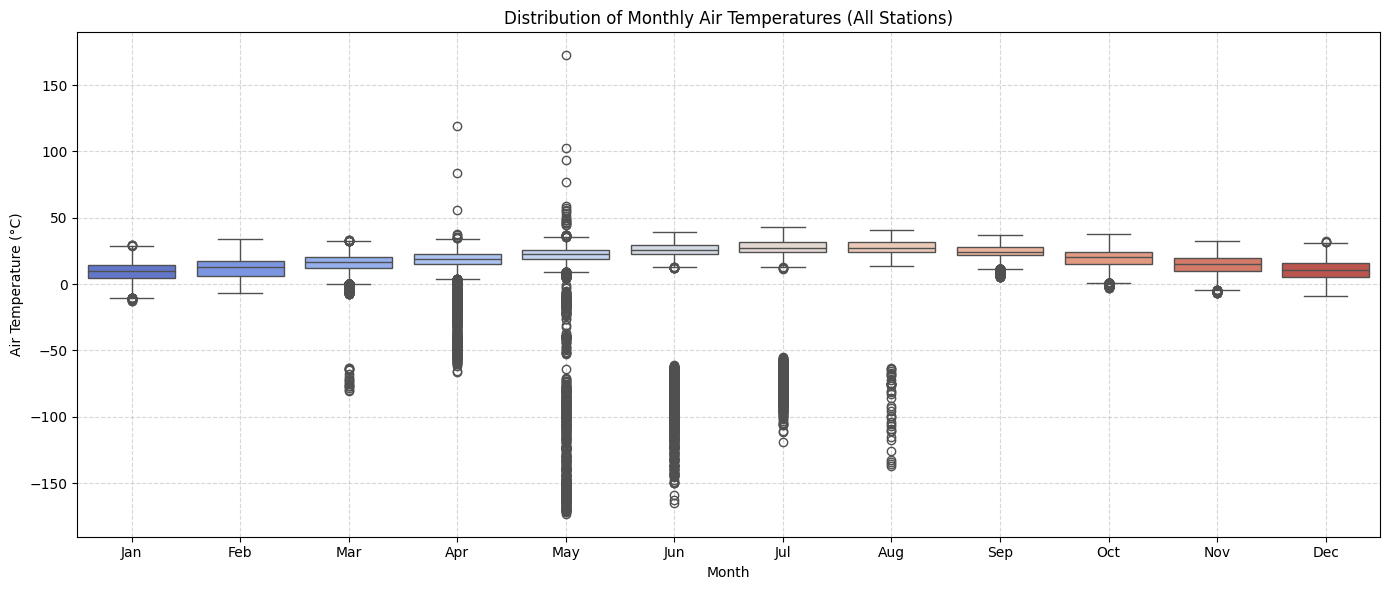

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map numeric month to name
month_name_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
combined_temp_df['Month Name'] = combined_temp_df['Month'].map(month_name_map)

# Order the months
combined_temp_df['Month Name'] = pd.Categorical(
    combined_temp_df['Month Name'],
    categories=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    ordered=True
)

# Plot
plt.figure(figsize=(14, 6))
sns.boxplot(data=combined_temp_df, x='Month Name', y='Tair', palette='coolwarm')
plt.title("Distribution of Monthly Air Temperatures (All Stations)")
plt.xlabel("Month")
plt.ylabel("Air Temperature (°C)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=8e560f6b-1726-4372-a865-7294f65e8413' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>